Topic: Movie Review Sentiment Analysis using LSTM

In [32]:
# read the dataset
import zipfile
import pandas as pd

with zipfile.ZipFile('/content/archive (2).zip', 'r') as z:
    df = pd.read_csv(z.open('IMDB Dataset.csv'))

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [30]:
#Check the data
print(df.shape)
print(df['sentiment'].value_counts())

(50000, 2)
Series([], Name: count, dtype: int64)


In [29]:
#Convert labels
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,NaN
1,A wonderful little production. <br /><br />The...,NaN
2,I thought this was a wonderful way to spend ti...,NaN
3,Basically there's a family where a little boy ...,NaN
4,"Petter Mattei's ""Love in the Time of Money"" is...",NaN


In [28]:
# Prepare text
texts = df['review']
labels = df['sentiment']

In [27]:
# Tokenization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

X = pad_sequences(sequences, maxlen=200)

In [26]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    random_state=42
)

In [25]:
# Build LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential()

model.add(
    Embedding(
        input_dim=5000,
        output_dim=32
    )
)

model.add(
    LSTM(64)
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 184ms/step - accuracy: 0.9186 - loss: 0.2053 - val_accuracy: 0.8865 - val_loss: 0.2998
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 175ms/step - accuracy: 0.9316 - loss: 0.1776 - val_accuracy: 0.8884 - val_loss: 0.2811
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 149ms/step - accuracy: 0.9422 - loss: 0.1515 - val_accuracy: 0.8880 - val_loss: 0.2946


In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8877 - loss: 0.2693
Test Accuracy: 0.8877000212669373


In [10]:
review = ["This movie was absolutely amazing"]

seq = tokenizer.texts_to_sequences(review)

pad = pad_sequences(seq, maxlen=200)

prediction = model.predict(pad)

print(prediction)

In [13]:
review = ["This movie was absolutely amazing"]

seq = tokenizer.texts_to_sequences(review)

pad = pad_sequences(seq, maxlen=200)

prediction = model.predict(pad)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
[[0.47850382]]


In [14]:
if prediction[0][0] > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review


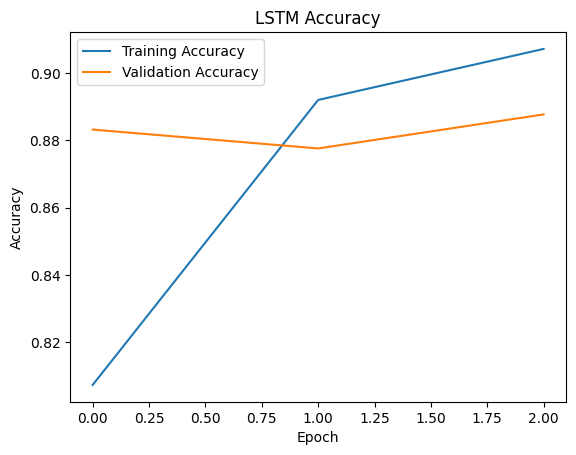

In [22]:
# accuracy graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8877 - loss: 0.2693
Accuracy: 0.8877000212669373


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


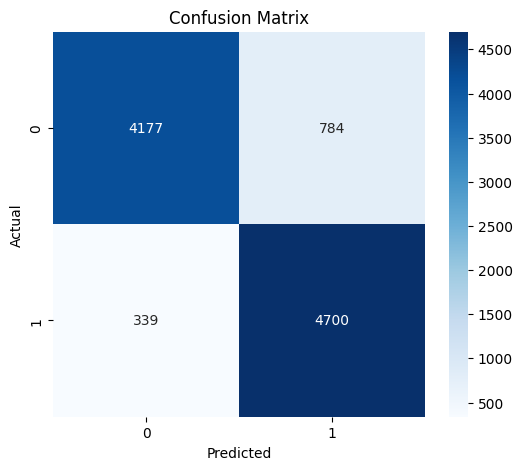

In [21]:
# Add Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
# Classifications Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.84      0.88      4961
           1       0.86      0.93      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Conclusion: This project implements an LSTM-based Deep Learning model for sentiment analysis on IMDb movie reviews. The reviews were preprocessed using tokenization and sequence padding. The LSTM network learned contextual information from text sequences and classified reviews as positive or negative. The model achieved an accuracy of 88.77%, demonstrating the effectiveness of LSTM networks in Natural Language Processing tasks.
